# Non-Linear

## Regressor Trees

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('Data TH_Gold-Prices.csv')

In [3]:
df.describe()

,GPT(THB),GPW(USD),CPI,IR,POIL(USD),EXR
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,23481.250000,1492.038500,100.463750,1.370833,63.729917,33.233936
std,4802.441879,297.166848,3.565235,0.564145,20.007970,1.808449
min,18000.000000,1057.800000,96.650000,0.500000,19.330000,29.985700
25%,19700.000000,1247.010000,97.997500,0.937500,48.665000,31.859600
50%,20825.000000,1321.685000,99.255000,1.500000,59.475000,32.956250
75%,28175.000000,1789.585000,100.375000,1.750000,75.932500,34.822025
max,34000.000000,2065.150000,108.410000,2.500000,112.100000,37.920400


### Data cleansing

#### Clean datetime

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

#### Drop unuse columns

In [5]:
df = df.drop(columns=['Date'])

#### Define target

In [6]:
target = 'GPT(THB)'

<Axes: >

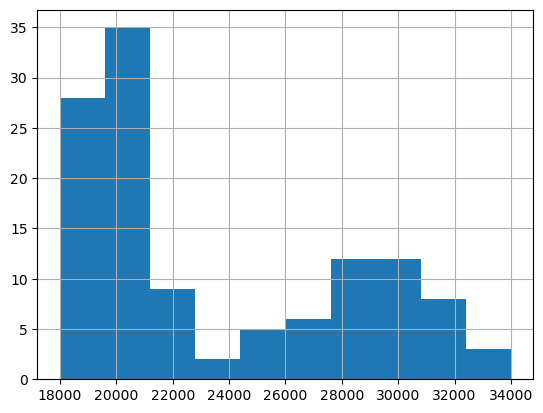

In [7]:
df[target].hist()

#### Check data type

In [8]:
df.dtypes

GPT(THB)       int64
GPW(USD)     float64
CPI          float64
IR           float64
POIL(USD)    float64
EXR          float64
dtype: object

#### Clean missing value

In [9]:
df.isnull().sum()

GPT(THB)     0
GPW(USD)     0
CPI          0
IR           0
POIL(USD)    0
EXR          0
dtype: int64

#### Assign target and features

In [10]:
features = [x for x in df.columns if x != target]

In [11]:
features

['GPW(USD)', 'CPI', 'IR', 'POIL(USD)', 'EXR']

In [12]:
y = df[target]
X = df[features]

### Split dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
X_train

,GPW(USD),CPI,IR,POIL(USD),EXR
30,1335.75,97.77,1.50,41.12,35.0706
53,1247.74,99.42,1.50,71.66,32.4702
118,2044.80,107.45,2.50,77.79,35.4656
9,1198.91,98.35,2.00,81.04,32.4575
33,1278.01,97.92,1.50,48.25,35.0603
...,...,...,...,...,...
106,1749.82,107.92,1.25,78.98,36.4265
14,1185.40,97.45,1.75,48.73,32.6340
92,1726.40,101.21,0.50,74.47,33.1190
51,1322.81,98.95,1.50,68.04,31.3148


In [15]:
y_train

30     22200
53     19650
118    33900
9      18150
33     21150
       ...  
106    29450
14     18200
92     27750
51     19700
102    30300
Name: GPT(THB), Length: 84, dtype: int64

### Feature selection

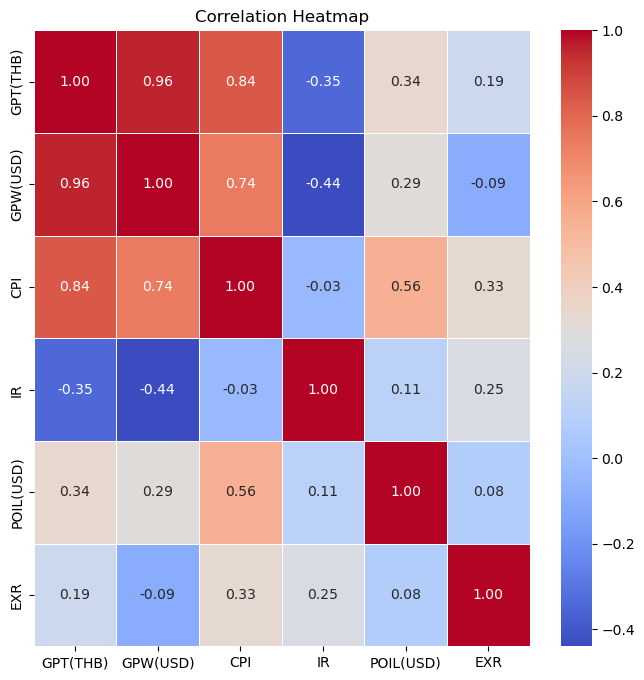

In [16]:
correlation_matrix = df.corr()

plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
features = [x for x in df.columns if x != target]

In [18]:
X_train = X_train[features]
X_test = X_test[features]

In [19]:
X_train

,GPW(USD),CPI,IR,POIL(USD),EXR
30,1335.75,97.77,1.50,41.12,35.0706
53,1247.74,99.42,1.50,71.66,32.4702
118,2044.80,107.45,2.50,77.79,35.4656
9,1198.91,98.35,2.00,81.04,32.4575
33,1278.01,97.92,1.50,48.25,35.0603
...,...,...,...,...,...
106,1749.82,107.92,1.25,78.98,36.4265
14,1185.40,97.45,1.75,48.73,32.6340
92,1726.40,101.21,0.50,74.47,33.1190
51,1322.81,98.95,1.50,68.04,31.3148


## Model

In [20]:
def get_feature_importances(model, X):
    """
    Get a feature importance dataFrame from best parameters.
    """
    importances = model.best_estimator_.feature_importances_

    importances_df = pd.DataFrame({
        'features': X.columns,
        'importances': importances
    })

    importances_df = importances_df.sort_values(by='importances', ascending=False)
    importances_df = importances_df.reset_index(drop=True)

    return importances_df

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Decision Tree

In [22]:
dt_param_grid = {
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [3, 5, 10],
    'min_samples_leaf': [1, 3, 6]
}

In [23]:
dt = DecisionTreeRegressor(random_state=42)
dt_model = GridSearchCV(estimator=dt, param_grid=dt_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
dt_model.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 5, 10, None],
                         'min_samples_leaf': [1, 3, 6],
                         'min_samples_split': [3, 5, 10]},
             scoring='neg_mean_squared_error')

In [24]:
get_feature_importances(dt_model, X_train)

,features,importances
0,GPW(USD),0.871211
1,CPI,0.095351
2,IR,0.017787
3,EXR,0.011262
4,POIL(USD),0.004389


### Random Forest

In [25]:
rf_param_grid = {
    'n_estimators': [25, 50, 75, 100, 200],
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [3, 5, 10],
    'min_samples_leaf': [1, 3, 6]
}

In [26]:
rf = RandomForestRegressor(random_state=42)
rf_model = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=kf, n_jobs=-1)
rf_model.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 5, 10, None],
                         'min_samples_leaf': [1, 3, 6],
                         'min_samples_split': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 200]})

In [27]:
get_feature_importances(rf_model, X_train)

,features,importances
0,GPW(USD),0.880729
1,CPI,0.070506
2,IR,0.022644
3,EXR,0.021249
4,POIL(USD),0.004872


### XGBoost

In [28]:
xgb_param_grid = {
    'n_estimators': [25, 50, 75, 100, 200],
    'max_depth': [2, 5, 10, None],
    'learning_rate': [0.01, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 0.1, 0]
}

In [29]:
xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model = GridSearchCV(estimator=xgb, param_grid=xgb_param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_model.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    inte...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [2, 5, 10, None],
                         'n_estimators': [25, 50, 75, 100, 200],
                         'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 0.1, 0]},
             scoring='neg_mean_squared_error')

In [30]:
get_feature_importances(xgb_model, X_train)

,features,importances
0,GPW(USD),0.772071
1,IR,0.097135
2,CPI,0.087273
3,POIL(USD),0.028876
4,EXR,0.014645


## Evaluate

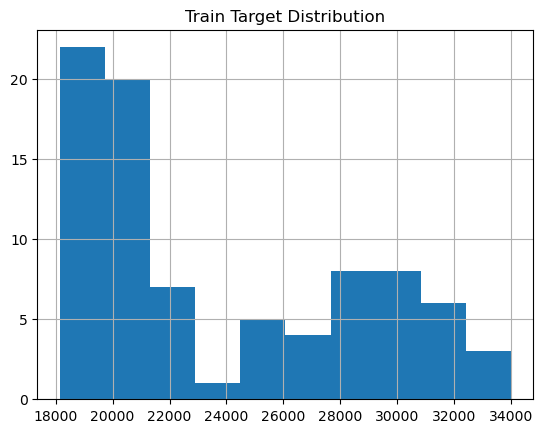

In [31]:
y_train.hist()
plt.title('Train Target Distribution')
plt.show()

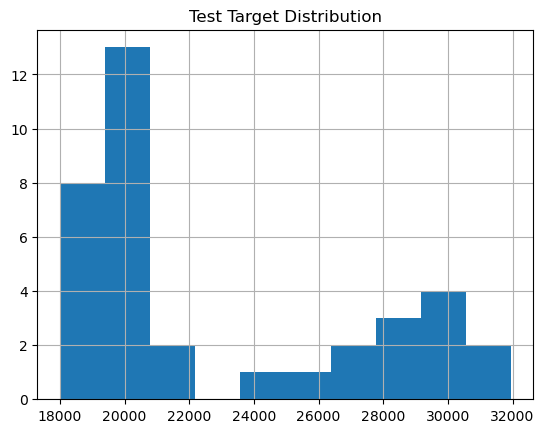

In [32]:
y_test.hist()
plt.title('Test Target Distribution')
plt.show()

### Decision Tree

In [33]:
y_pred_train = dt_model.best_estimator_.predict(X_train)
mean_squared_error(y_pred_train, y_train)

9880.952380952382

In [34]:
y_pred = dt_model.best_estimator_.predict(X_test)
mean_squared_error(y_pred, y_test)

739270.8333333334

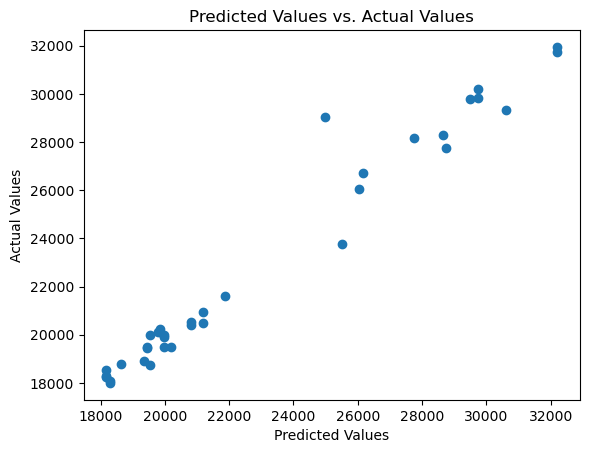

In [35]:
plt.scatter(y_pred, y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Predicted Values vs. Actual Values')
plt.show()

### Random Forest

In [36]:
y_pred = rf_model.best_estimator_.predict(X_train)
mean_squared_error(y_pred, y_train)

68855.68662104459

In [37]:
y_pred = rf_model.best_estimator_.predict(X_test)
mean_squared_error(y_pred, y_test)

342988.9858977383

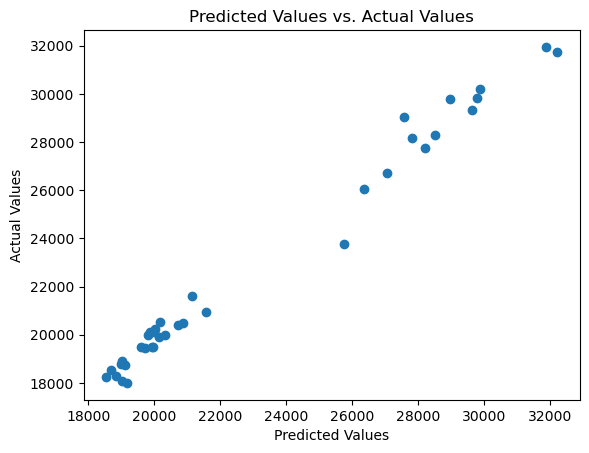

In [38]:
plt.scatter(y_pred, y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Predicted Values vs. Actual Values')
plt.show()

### XGBoost

In [39]:
y_pred = xgb_model.best_estimator_.predict(X_train)
mean_squared_error(y_pred, y_train)

15482.774421601069

In [40]:
y_pred = xgb_model.best_estimator_.predict(X_test)
mean_squared_error(y_pred, y_test)

151910.19881545173

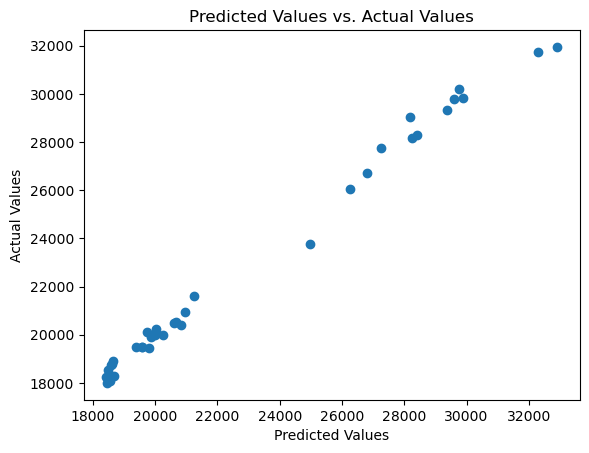

In [41]:
plt.scatter(y_pred, y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Predicted Values vs. Actual Values')
plt.show()

## Test run

In [42]:
input = {
        'GPW(USD)': 1427.87,
        'CPI': 106.95,
        'IR': 2,
        'POIL(USD)': 80.21,
        'EXR': 33.82
}

In [43]:
input_df = pd.DataFrame(input, index=[0])

In [44]:
input_df

,GPW(USD),CPI,IR,POIL(USD),EXR
0,1427.87,106.95,2,80.21,33.82


In [45]:
dt_model.best_estimator_.predict(input_df)

array([21200.])

In [46]:
rf_model.best_estimator_.predict(input_df)

array([20660.58333333])

In [47]:
xgb_model.best_estimator_.predict(input_df)

array([21940.176], dtype=float32)